# Intraday Momentum Strategy on SPY




**Strategy.** For each time of day, the Noise Area is the range within which SPY usually moves relative to its open. A price outside this range indicates an imbalance between supply and demand, and the strategy trades in the direction of the move: long above the upper band, short below the lower band. All positions are closed at 16:00.

**Price convention.** A check at time $T$ (10:00, 10:30, …, 15:30) uses the close of the 30-minute bar ending at $T$. Trades are filled at this price. The day ends with the close of the bar ending at 16:00.

**Train / test split.** Train: 2016–2021. Test: 2022 – October 2026. All parameters of the replication are taken from the paper; none is estimated on the data. The choice of the split date and its robustness are discussed in Section 5.1.

## 0. Parameters
Commission corresponds to the Interactive Brokers entry tier and slippage to the value measured in the paper.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

START_AUM   = 100_000 
COMMISSION  = 0.0035   # $ per share (paper)
SLIPPAGE    = 0.001    # $ per share (paper)
LOOKBACK    = 14       # days for the Noise Area
TRAIN_END   = '2021-12-31'   # train: 2016-2021, test: 2022 onwards 

## 1. Data: day × time tables
* `spy_30min.csv`: SPY 30-minute bars, regular trading hours (13 bars per day, fewer on early-close days).
* `spy_daily.csv`: SPY daily prices; `close` is used for the volatility estimate, `adj_close` (dividends included) for the buy-and-hold benchmark.
* `vix_daily.csv`: VIX daily prices (Section 6).

All quantities are stored with one row per day and one column per time of day, so that the same time of day on previous days corresponds to the rows above in the same column.

The cumulative VWAP since the open is
$$VWAP_{t,T} = \frac{\sum_{\tau \le T} \text{vwap}_{t,\tau}\cdot \text{volume}_{t,\tau}}{\sum_{\tau \le T} \text{volume}_{t,\tau}}$$

In [ ]:

bars = pd.read_csv('data/spy_30min.csv')
bars['date'] = pd.to_datetime(bars['date'])
bars['time'] = bars['bar_end'].str[11:16]          # '10:00', ..., '16:00'
# one row per day, one column per time of day
close = bars.pivot(index='date', columns='time', values='close')
day_open = bars.groupby('date')['open'].first()     # 9:30 open
day_close = bars.groupby('date')['close'].last()    # 16:00 close (13:00 on early-close days)
prev_close = day_close.shift(1)

# cumulative intraday VWAP at each time (for the extension)
bars['pv'] = bars['vwap'] * bars['volume']
g = bars.groupby('date')
bars['vwap_cum'] = g['pv'].cumsum() / g['volume'].cumsum()
vwap = bars.pivot(index='date', columns='time', values='vwap_cum')

close.iloc[:3]

time,10:00,10:30,11:00,11:30,12:00,12:30,13:00,13:30,14:00,14:30,15:00,15:30,16:00
date,,,,,,,,,,,,,
2016-01-04,200.22,199.840,199.1400,199.145,199.38,199.37,199.7901,199.915,199.910,199.9149,199.60,199.2100,200.99
2016-01-05,200.92,200.445,201.3099,200.750,200.88,200.40,200.6000,200.600,201.280,201.7000,201.35,201.2308,201.43
2016-01-06,199.20,199.630,199.2600,199.810,199.32,199.18,199.2300,198.950,198.731,198.9900,197.75,198.5000,198.79


## 2. Noise Area (paper, Section 3)

$$\text{move}_{t,T} = \left|\frac{P_{t,T}}{Open_t} - 1\right| \qquad
\sigma_{t,T} = \frac{1}{14}\sum_{i=1}^{14} \text{move}_{t-i,\,T}$$

$$UB_{t,T} = \max(Open_t,\ Close_{t-1}) \cdot (1 + \sigma_{t,T}) \qquad
LB_{t,T} = \min(Open_t,\ Close_{t-1}) \cdot (1 - \sigma_{t,T})$$

* The rolling mean is taken over the same time of day on the previous 14 days; `shift(1)` excludes the current day.
* On early-close days afternoon prices are missing; `dropna()` per column ensures that σ is always based on the last 14 observations of that time slot.
* The maximum and minimum with the previous close adjust the bands for overnight gaps.

The figure shows 20 January 2022, the example day used in the paper (Figures 4–5).

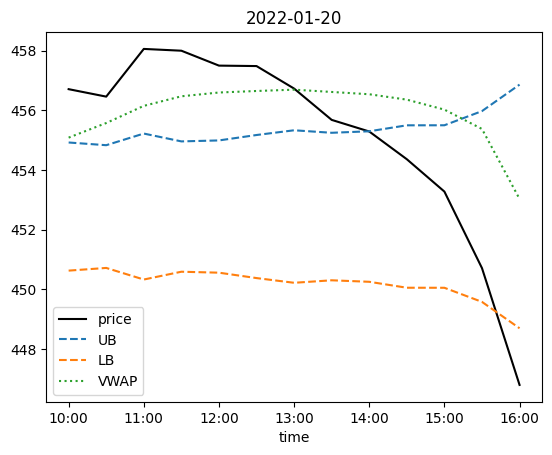

In [33]:
move  = close.div(day_open, axis=0).sub(1).abs()
sigma = move.apply(lambda col: col.dropna().rolling(14).mean().shift(1)).reindex(move.index)

ref_up = np.maximum(day_open, prev_close)
ref_dn = np.minimum(day_open, prev_close)
UB = (1 + sigma).mul(ref_up, axis=0)
LB = (1 - sigma).mul(ref_dn, axis=0)

# sanity plot: one day vs. Figure 4 of the paper
d = '2022-01-20'
ax = close.loc[d].plot(label='price', color='k')
UB.loc[d].plot(ax=ax, ls='--', label='UB'); LB.loc[d].plot(ax=ax, ls='--', label='LB')
vwap.loc[d].plot(ax=ax, ls=':', label='VWAP'); ax.legend(); ax.set_title(d); plt.show()

## 3. Signals and positions

Positions $pos_{t,T} \in \{-1, 0, +1\}$ are set at $T$ = 10:00, …, 15:30 and held until the next check. All positions are closed at 16:00.

**Base strategy (paper, Section 3).**
$$pos_{t,T} = \begin{cases} +1 & P_{t,T} > UB_{t,T} \\ -1 & P_{t,T} < LB_{t,T} \\ pos_{t,T-1} & \text{otherwise} \end{cases}$$
A position is closed only when the price crosses the opposite band, which reverses it, or at the close.

**VWAP trailing stop (paper, Section 3.2).**
$$pos_{t,T} = \begin{cases} +1 & P_{t,T} > \max(UB_{t,T},\ VWAP_{t,T}) \\ -1 & P_{t,T} < \min(LB_{t,T},\ VWAP_{t,T}) \\ 0 & \text{otherwise} \end{cases}$$
A position is closed as soon as the price moves back through VWAP or into the Noise Area.

In [34]:
check_times = [t for t in close.columns if '10:00' <= t <= '15:30']
px = close[check_times]

def base_positions():
    sig = pd.DataFrame(np.nan, index=px.index, columns=check_times)
    sig[px > UB[check_times]] = 1
    sig[px < LB[check_times]] = -1
    return sig.ffill(axis=1).fillna(0)          # hold until the opposite band; ffill only within the day

def vwap_stop_positions():
    up = np.maximum(UB[check_times], vwap[check_times])
    dn = np.minimum(LB[check_times], vwap[check_times])
    pos = pd.DataFrame(0.0, index=px.index, columns=check_times)
    pos[px > up] = 1
    pos[px < dn] = -1
    return pos

pos_base = base_positions()
pos_ext  = vwap_stop_positions()
pos_base.iloc[20:23]

,10:00,10:30,11:00,11:30,12:00,12:30,13:00,13:30,14:00,14:30,15:00,15:30
date,,,,,,,,,,,,
2016-02-02,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2016-02-03,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2016-02-04,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 4. Position sizing, costs and backtest (paper, Sections 3.1 and 3.3)

**Leverage.**
$$L_t = \begin{cases} 1 & \text{fixed size} \\ \min\!\left(4,\ \dfrac{0.02}{\sigma_{SPY,t}}\right) & \text{volatility targeting} \end{cases}$$
$\sigma_{SPY,t}$ is the sample standard deviation of SPY's daily returns over days $t-14, \dots, t-1$. Since the daily risk of the position is approximately $L_t\,\sigma_{SPY,t}$, this rule targets a daily risk of 2%: exposure increases when the market is calm and decreases when it is volatile. The cap of 4× corresponds to the usual intraday margin limit.

**Number of shares** (fixed for the day):
$$N_t = \left\lfloor \frac{AUM_{t-1}\cdot L_t}{Open_t} \right\rfloor$$

**Gross P&L per share.** The position chosen at $T$ earns the price change until the next check $T^{+}$ (the last one is the 16:00 close):
$$g_t = \sum_{T} pos_{t,T}\,\big(P_{t,T^{+}} - P_{t,T}\big)$$
`diff` stores $P_{t,T} - P_{t,T^{-}}$ under the later time; the columns of `dprice` are therefore shifted back to the decision time. The price change is only used to evaluate a position after it was taken, so no future information enters the signal.

**Turnover and costs.**
$$\tau_t = \sum_{T} \big|pos_{t,T} - pos_{t,T^{-}}\big| \qquad \text{Costs}_t = N_t\,\tau_t\,(0.0035 + 0.001)$$
The position is zero before the first and after the last check, so entry, exit and reversals (counted twice) are all charged.

**Return and capital.**
$$PnL_t = N_t\,g_t - \text{Costs}_t \qquad r_t = \frac{PnL_t}{AUM_{t-1}} \qquad AUM_t = AUM_{t-1} + PnL_t$$

**Benchmark.** SPY buy and hold, based on daily `adj_close` returns.

In [ ]:
TARGET_VOL = 0.02            # daily volatility target (paper)
MAX_LEV    = 4               # leverage cap (paper)
TEST_START = '2022-01-01'

path = close[check_times].copy()
path['close'] = day_close
dprice = path.diff(axis=1).iloc[:, 1:]            # P_{T+1} - P_T, stored under T+1 ...
dprice.columns = check_times                       # ... relabelled to T (time of the decision)

spy_daily = pd.read_csv('data/spy_daily.csv', parse_dates=['date']).set_index('date')
daily_ret_spy = spy_daily['close'].pct_change()
vol_14 = daily_ret_spy.rolling(14).std().shift(1).reindex(day_open.index)
lev_vol = (TARGET_VOL / vol_14).clip(upper=MAX_LEV).fillna(1)
lev_one = pd.Series(1.0, index=day_open.index)

def backtest(pos, lev):
    pos = pos.fillna(0)
    p = pos.copy(); p.insert(0, 'start', 0.0); p['end'] = 0.0
    turnover = p.diff(axis=1).abs().sum(axis=1)              # blocks of N shares traded
    gross_per_share = (pos * dprice).sum(axis=1)             # g_t

    aum, rows = START_AUM, []
    for d in pos.index:
        if np.isnan(UB.loc[d, '10:00']):                     # warm-up day: no bands yet
            rows.append((d, 0.0, aum, 0.0)); continue
        shares = np.floor(aum * lev[d] / day_open[d])        # N_t
        pnl = shares * gross_per_share[d] - shares * turnover[d] * (COMMISSION + SLIPPAGE)
        rows.append((d, pnl / aum, aum + pnl, shares * turnover[d]))
        aum += pnl
    out = pd.DataFrame(rows, columns=['date', 'ret', 'aum', 'shares_traded']).set_index('date')
    return out.loc[UB['10:00'].first_valid_index():]

res = {
    'Base':                   backtest(pos_base, lev_one),
    'Base + VWAP stop':       backtest(pos_ext,  lev_one),
    'VWAP stop + vol sizing': backtest(pos_ext,  lev_vol),
}
bh = spy_daily['adj_close'].pct_change().reindex(day_open.index).fillna(0)
bh = bh.loc[res['Base'].index[0]:]
res['SPY buy & hold'] = pd.DataFrame({'ret': bh, 'aum': START_AUM * (1 + bh).cumprod()})

## 5. Metrics and train / test evaluation

| Metric | Definition |
|---|---|
| Annualized return | $\left(\prod_t (1+r_t)\right)^{252/n} - 1$ |
| Annualized volatility | $\text{std}(r_t)\sqrt{252}$ |
| Sharpe ratio | $\bar r \cdot 252 \,/\, \big(\text{std}(r_t)\sqrt{252}\big)$, with $r_f = 0$ |
| Maximum drawdown | $\min_t \left(E_t / \max_{s\le t} E_s - 1\right)$, with $E_t = \prod_{s \le t}(1+r_s)$ |
| Hit ratio | share of days with $r_t \ne 0$ on which $r_t > 0$ |

Leverage scales return and volatility proportionally, so the Sharpe ratio is the relevant measure for comparing fixed-size and volatility-targeted versions.

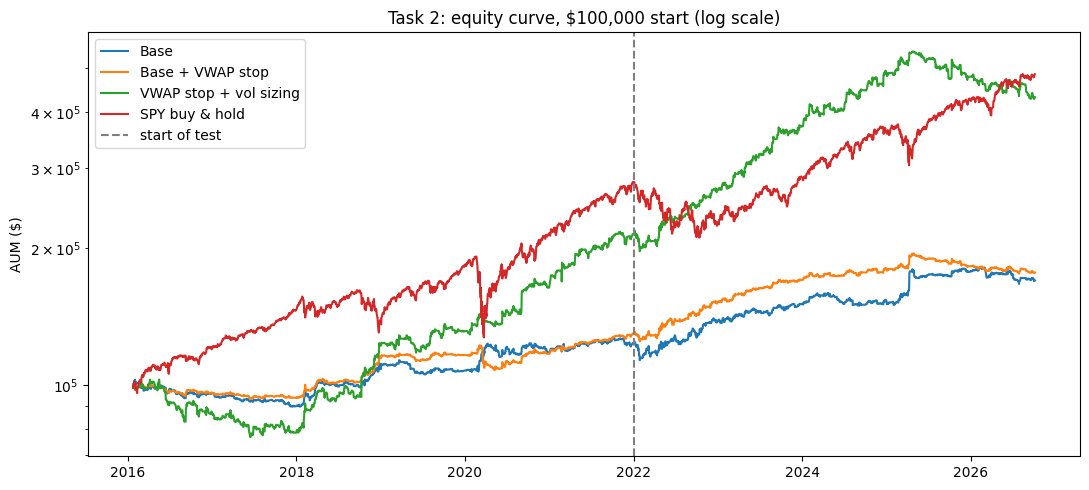

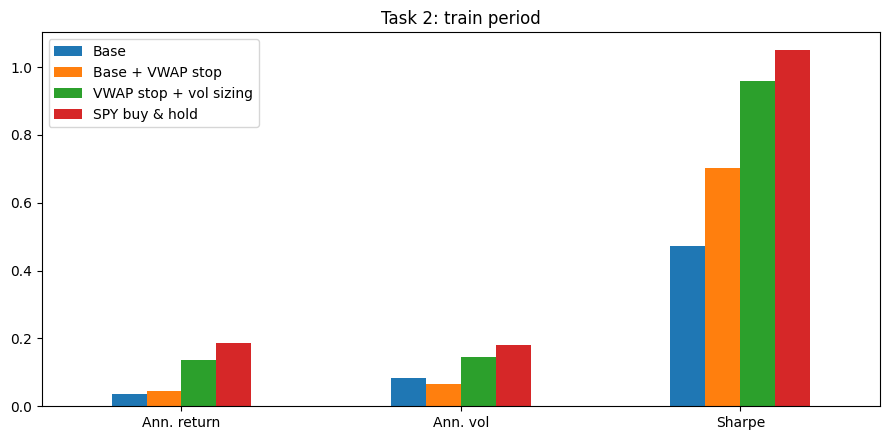

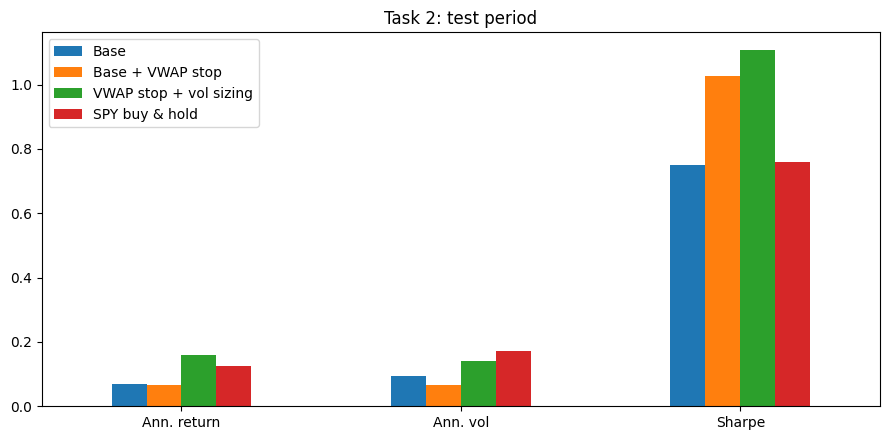

Ann. return  Ann. vol  Sharpe  Max DD  Hit ratio
Base                   train         0.04      0.08    0.47   -0.13       0.53
                       test          0.07      0.10    0.75   -0.09       0.56
Base + VWAP stop       train         0.04      0.07    0.70   -0.12       0.42
                       test          0.07      0.07    1.03   -0.10       0.46
VWAP stop + vol sizing train         0.14      0.15    0.96   -0.25       0.42
                       test          0.16      0.14    1.11   -0.21       0.46
SPY buy & hold         train         0.19      0.18    1.05   -0.34       0.57
                       test          0.12      0.17    0.76   -0.24       0.54

In [36]:
def metrics(r):
    ann_ret = (1 + r).prod() ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    eq = (1 + r).cumprod()
    return pd.Series({'Ann. return': ann_ret, 'Ann. vol': ann_vol,
                      'Sharpe': r.mean() * 252 / ann_vol, 'Max DD': (eq / eq.cummax() - 1).min(),
                      'Hit ratio': (r[r != 0] > 0).mean()})

def metric_table(names):
    rows = {}
    for n in names:
        rows[(n, 'train')] = metrics(res[n].loc[:TRAIN_END, 'ret'])
        rows[(n, 'test')]  = metrics(res[n].loc[TEST_START:, 'ret'])
    return pd.DataFrame(rows).T

def plot_results(names, tbl, title):
    # equity curves
    fig, ax = plt.subplots(figsize=(11, 5))
    for n in names:
        ax.plot(res[n].index, res[n]['aum'], label=n)
    ax.set_yscale('log'); ax.axvline(pd.Timestamp(TEST_START), color='grey', ls='--', label='start of test')
    ax.set_title(f'{title}: equity curve, $100,000 start (log scale)'); ax.set_ylabel('AUM ($)')
    ax.legend(); plt.tight_layout(); plt.show()
    # metrics, one figure per period
    for part in ['train', 'test']:
        fig, ax = plt.subplots(figsize=(9, 4.5))
        tbl.xs(part, level=1)[['Ann. return', 'Ann. vol', 'Sharpe']].T.plot.bar(ax=ax, rot=0)
        ax.set_title(f'{title}: {part} period'); ax.axhline(0, color='k', lw=0.5); ax.legend()
        plt.tight_layout(); plt.show()

table = metric_table(res)
plot_results(list(res), table, 'Task 2')
table.round(2)

### Interpretation

* Each step of the paper raises the Sharpe ratio in both periods (train 0.47 → 0.70 → 0.96, test 0.75 → 1.03 → 1.11), in the same order as reported in the paper.
* The VWAP stop leaves the return unchanged and lowers volatility (test: 10% → 7%). Positions are closed earlier, which lowers the hit ratio (≈ 53% → 42%) but limits losses on reversals.
* Volatility targeting raises the return from 7% to 16% at 14% volatility. The effect comes mainly from higher average exposure; the Sharpe ratio improves slightly and the maximum drawdown doubles.
* Against SPY: in the train period (2016–2021) buy and hold has the higher Sharpe ratio (1.05 vs 0.96). In the test period (2022+, including the 2022 decline) the strategy has a higher Sharpe ratio (1.11 vs 0.76), a higher return (16% vs 12%) and lower volatility and drawdown. This comparison depends on the split date (Section 5.1).
* The better test result is not a sign of overfitting, since no parameter was estimated. It reflects market conditions: 2016–2017 were calm years without trends and the strategy lost money, while 2022–2024 were favourable.

### Comparison with the paper (Table 3, 2007–2024)

Volatility (7% and 14% vs 7.7% and 14.3%) and hit ratios (≈ 54% base, ≈ 43–46% with VWAP stop) are close to the paper. The Sharpe ratios are lower (≈ 1.0–1.1 vs 1.24–1.33), mainly because of the sample period: the paper includes 2008–2009, 2011 and 2020, periods of high volatility and strong intraday trends, while our sample contains the calm years 2016–2017 and the weak years 2025–2026.

### Assumptions
* Costs: \$0.0035 commission and \$0.001 slippage per share.
* Fills at the check price; no financing costs, since no position is held overnight.
* Sharpe ratio with $r_f = 0$.
* 30-minute bars instead of 1-minute data. Checks take place at the same times as in the paper (HH:00 and HH:30), so entry and exit prices are unaffected.

### 5.1 Choice of the split date

The paper does not split its sample (May 2007 – April 2024). It addresses overfitting by using few parameters, by not choosing their optimal values (a 90-day lookback or a volatility multiplier of 1.5 would give higher Sharpe ratios) and by sensitivity tests (Appendix, Q6 and Q14). We add a chronological out-of-sample test. The split is chronological rather than random, since neighbouring days share information through rolling windows and volatility regimes.

The boundary at the end of 2021 was fixed in advance: it gives a split of about 56/44 on the calendar-year boundary closest to 60/40. Common machine-learning proportions (70/30, 80/20) are designed for models whose parameters are estimated on the training set; here no parameter is estimated, so a larger test share is preferable because it covers more market conditions. A 70/30 or 80/20 split would start the test period in mid-2023 or mid-2024 and exclude the 2022 decline.

The date is not selected from the data, which would risk data snooping. Instead, two checks show whether the conclusions depend on it:
1. the Sharpe ratios for alternative split dates between the end of 2020 and the end of 2022;
2. Chow tests for a structural break at the split, with heteroskedasticity- and autocorrelation-robust (HAC) standard errors, since the variance of daily returns changes strongly over time.

In [37]:
sharpe = lambda x: x.mean() / x.std() * np.sqrt(252)
cuts = ['2020-12-31', '2021-12-31', '2022-06-30', '2022-12-31']
names = ['Base', 'Base + VWAP stop', 'VWAP stop + vol sizing', 'SPY buy & hold']

rows = {}
for cut in cuts:
    for part, sl in [('train', slice(None, cut)), ('test', slice(pd.Timestamp(cut) + pd.Timedelta(days=1), None))]:
        rows[(cut, part)] = {n: sharpe(res[n].loc[sl, 'ret']) for n in names}
        rows[(cut, part)]['days'] = len(res['Base'].loc[sl])
split_table = pd.DataFrame(rows).T
split_table[names] = split_table[names].round(2)
split_table.astype({'days': int})

Base  Base + VWAP stop  VWAP stop + vol sizing  \
2020-12-31 train  0.43              0.50                    0.76   
           test   0.75              1.17                    1.25   
2021-12-31 train  0.47              0.70                    0.96   
           test   0.75              1.03                    1.11   
2022-06-30 train  0.46              0.76                    0.97   
           test   0.84              1.00                    1.11   
2022-12-31 train  0.56              0.89                    1.06   
           test   0.70              0.75                    0.96   

                  SPY buy & hold  days  
2020-12-31 train            0.92  1245  
           test             0.93  1445  
2021-12-31 train            1.05  1497  
           test             0.76  1193  
2022-06-30 train            0.76  1621  
           test             1.22  1069  
2022-12-31 train            0.72  1748  
           test             1.43   942

In [38]:
import statsmodels.api as sm

def chow_hac(y, X, date):
    # Wald test that all coefficients are equal before and after `date` (HAC standard errors)
    post = (y.index >= date).astype(float)
    Xf = pd.concat([X, X.mul(post, axis=0).add_suffix('_post')], axis=1)
    fit = sm.OLS(y, Xf).fit(cov_type='HAC', cov_kwds={'maxlags': 10})
    w = fit.wald_test(', '.join(f'{c}_post = 0' for c in X.columns), scalar=True)
    return w.statistic, w.pvalue

def sup_f_date(y, X, trim=0.15):
    # classical Chow F statistic for every candidate break date; returns the date of the maximum
    ssr = lambda yy, XX: np.linalg.lstsq(XX, yy, rcond=None)[1][0]   # residual sum of squares
    yv, Xv = y.values, X.values
    n, k = Xv.shape
    s_all = ssr(yv, Xv)
    F = {y.index[i]: ((s_all - ssr(yv[:i], Xv[:i]) - ssr(yv[i:], Xv[i:])) / k)
                     / ((ssr(yv[:i], Xv[:i]) + ssr(yv[i:], Xv[i:])) / (n - 2 * k))
         for i in range(int(n * trim), int(n * (1 - trim)))}
    return pd.Series(F).idxmax().date()

r_spy   = res['SPY buy & hold']['ret']
r_strat = res['VWAP stop + vol sizing']['ret']
models = {
    'Market: SPY r_t on const, r_{t-1}':        (r_spy.iloc[1:], pd.DataFrame({'const': 1.0, 'lag': r_spy.shift(1).iloc[1:]})),
    'Strategy on SPY: r_t = alpha + beta r_SPY': (r_strat,       pd.DataFrame({'const': 1.0, 'spy': r_spy})),
}
out = {}
for name, (y, X) in models.items():
    stat, p = chow_hac(y, X, TEST_START)
    out[name] = {'robust chi2 at split': round(stat, 2), 'p-value': round(p, 3), 'strongest break (classical sup-F)': sup_f_date(y, X)}
pd.DataFrame(out).T

,robust chi2 at split,p-value,strongest break (classical sup-F)
"Market: SPY r_t on const, r_{t-1}",4.4,0.111,2020-03-25
Strategy on SPY: r_t = alpha + beta r_SPY,0.77,0.681,2018-12-26


**Interpretation.**
* For every split date, each step of the paper raises the Sharpe ratio, and the final version has a test-period Sharpe ratio of about 1.0–1.25. These conclusions do not depend on the date.
* The comparison with SPY does depend on it: SPY has the higher test-period Sharpe ratio whenever the 2022 decline falls into the train period, because the test period then consists mainly of the 2023–2026 bull market.
* In the regression of strategy returns on SPY returns there is no structural break at the split (robust p ≈ 0.7): the relation between strategy and market is stable, so train and test results are comparable.
* In the market itself, the strongest break lies in March 2020 rather than at the end of 2021. With robust standard errors the break at the split is not significant at 5% (p ≈ 0.1); a classical Chow test would indicate one, but it assumes constant variance, which daily returns violate.

## 6. Extension: reduced exposure on calm days

**Motivation.** The paper (Section 4.1, Fig. 8) reports that the Sharpe ratio of the strategy increases with the VIX at the open and suggests that exposure could be adjusted to current market volatility, without implementing such a rule. Intraday momentum relies on order imbalances; on calm days breakouts from the Noise Area are more likely to reverse.

**Rule.**
$$L_t^{new} = \begin{cases} 0.5\, L_t & \text{if } \text{VIX}_{t,open} < c \\ L_t & \text{otherwise} \end{cases}$$
where $L_t$ is the paper's volatility-targeted leverage. The VIX at the open is known before the first check. Signals, costs and metrics are unchanged.

**Approach.** Calm days are concentrated in a few years (2016–2019 and 2023–2024), so a chronological split compares the rule on different calm regimes. The threshold $c$ is therefore derived from the distribution of the VIX alone, and the effect is evaluated on the full sample with block-bootstrap confidence intervals, in addition to the train/test split.

1. VIX distribution in the train and test periods (6.1) and two example days (6.2).
2. Definition of calm, normal and stressed days by VIX terciles (6.3).
3. Performance of the strategy by regime (6.4) and stability over time (6.5).
4. Backtest of the rule and test of the Sharpe difference (6.6).

### 6.1 VIX in the train and test periods
`r_paper` is the paper's final version (VWAP stop and volatility targeting). `r_unlev` uses the same signals with constant leverage of 1 and is used to compare signal quality across regimes.

In [ ]:
vix = pd.read_csv('data/vix_daily.csv', parse_dates=['date']).set_index('date')
vix_open = vix['open'].reindex(day_open.index).ffill()   # VIX at the open, known before the first check

TRAIN, TEST = slice(None, TRAIN_END), slice(TEST_START, None)
r_paper = res['VWAP stop + vol sizing']['ret']
r_unlev = backtest(pos_ext, lev_one)['ret']
v = vix_open.loc[r_paper.index]

def desc(x):
    return pd.Series({'days': len(x), 'mean': x.mean(), 'median': x.median(), 'std': x.std(),
                      'min': x.min(), 'max': x.max(),
                      '% <15':   (x < 15).mean() * 100,
                      '% 15-20': x.between(15, 20, inclusive='left').mean() * 100,
                      '% 20-30': x.between(20, 30, inclusive='left').mean() * 100,
                      '% >=30':  (x >= 30).mean() * 100})

pd.DataFrame({'train 2016-21': desc(v.loc[TRAIN]), 'test 2022+': desc(v.loc[TEST]), 'full': desc(v)}).T.round(1)

,days,mean,median,std,min,max,% <15,% 15-20,% 20-30,% >=30
train 2016-21,1497.0,18.1,16.0,8.3,9.0,82.7,43.5,27.9,22.6,6.1
test 2022+,1193.0,19.3,17.8,5.5,11.5,60.1,21.0,44.6,28.6,5.9
full,2690.0,18.6,16.9,7.2,9.0,82.7,33.5,35.3,25.2,6.0


The mean VIX is similar in both periods (18.1 and 19.3), but its distribution differs: 43.5% of train days have a VIX below 15, compared with 21% of test days, and the minimum in the test period is 11.5 against 9.0 in train.

### 6.2 Example days
A calm day (9 June 2017) and a volatile day (8 February 2018), both with the VWAP-stop signals. On the calm day the price repeatedly crosses the bands, which leads to several position changes and a loss; on the volatile day a single breakout continues until the close.

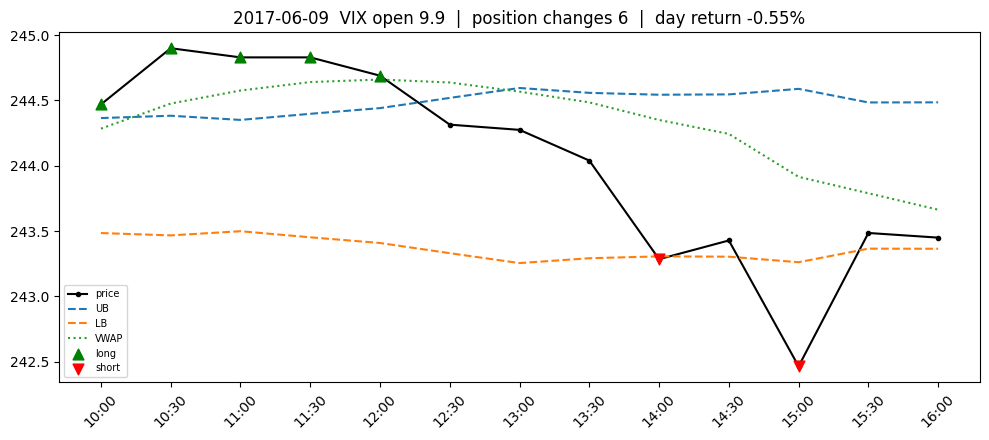

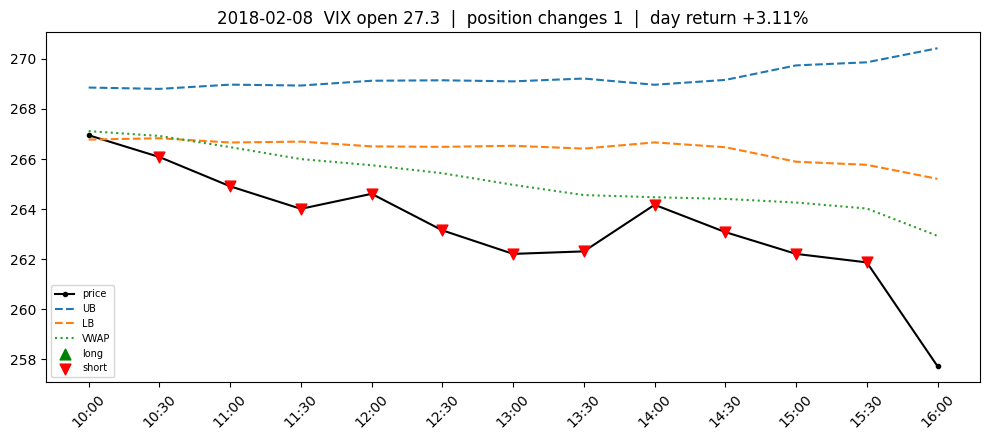

In [40]:
def plot_day(ax, d):
    ax.plot(close.loc[d].index, close.loc[d], 'k-o', ms=3, label='price')
    ax.plot(UB.loc[d], '--', label='UB'); ax.plot(LB.loc[d], '--', label='LB'); ax.plot(vwap.loc[d], ':', label='VWAP')
    p = pos_ext.loc[d]
    ax.scatter(p.index[p > 0], px.loc[d][p > 0], c='g', marker='^', s=60, zorder=3, label='long')
    ax.scatter(p.index[p < 0], px.loc[d][p < 0], c='r', marker='v', s=60, zorder=3, label='short')
    changes = int((p.diff().fillna(p).abs() > 0).sum())
    ax.set_title(f'{d}  VIX open {vix_open[d]:.1f}  |  position changes {changes}  |  day return {r_unlev[d]:+.2%}')
    ax.tick_params(axis='x', rotation=45); ax.legend(fontsize=7)

for d in ['2017-06-09', '2018-02-08']:          # calm day, volatile day
    fig, ax = plt.subplots(figsize=(10, 4.5))
    plot_day(ax, d)
    plt.tight_layout(); plt.show()

### 6.3 Regimes based on VIX terciles
All days are divided into three groups of equal size by the VIX at the open. The boundaries depend only on the VIX, not on strategy returns, and each regime contains about 900 days.

In [41]:
q1, q2 = v.quantile([1/3, 2/3])
regime = pd.cut(v, [0, q1, q2, 200], labels=['calm', 'normal', 'stressed'])
print(f'VIX terciles: {q1:.1f}, {q2:.1f}')
calm = vix_open < q1

VIX terciles: 15.0, 19.6


The lower tercile equals 15.0, which is used as the threshold $c$.

### 6.4 Performance by regime
Mean daily return of the fixed-size strategy in basis points (1 bp = 0.01%), with 95% confidence intervals from a block bootstrap. Daily returns are clustered in volatility regimes, so the sample is resampled in blocks of 21 consecutive trading days (3,000 replications). An interval that does not contain zero indicates a mean significantly different from zero at the 5% level.

In [42]:
def block_idx(n, block, rng):
    starts = rng.integers(0, n - block, int(np.ceil(n / block)))
    return (starts[:, None] + np.arange(block)).ravel()[:n]

rng, B, block = np.random.default_rng(0), 3000, 21
a, g = r_unlev.values, regime.values
boot = {k: [] for k in ['calm', 'normal', 'stressed']}; diff = []
for _ in range(B):
    idx = block_idx(len(a), block, rng); x, gg = a[idx], g[idx]
    for k in boot: boot[k].append(x[gg == k].mean())
    diff.append(x[gg == 'calm'].mean() - x[gg != 'calm'].mean())

tab = pd.DataFrame({k: {'days': (regime == k).sum(),
                        'mean bp': r_unlev[regime == k].mean() * 1e4,
                        'CI 2.5%': np.percentile(boot[k], 2.5) * 1e4,
                        'CI 97.5%': np.percentile(boot[k], 97.5) * 1e4,
                        'Sharpe': sharpe(r_unlev[regime == k]),
                        'win rate': (r_unlev[(regime == k) & (r_unlev != 0)] > 0).mean()}
                    for k in boot}).T
display(tab.round(2))
diff = np.array(diff) * 1e4
print(f'calm minus rest: {np.mean(diff):.2f} bp/day, 95% CI [{np.percentile(diff, 2.5):.2f}, {np.percentile(diff, 97.5):.2f}]')

,days,mean bp,CI 2.5%,CI 97.5%,Sharpe,win rate
calm,901.0,0.57,-0.65,1.74,0.44,0.39
normal,892.0,1.93,-0.17,4.33,0.90,0.43
stressed,897.0,4.12,0.79,7.56,1.10,0.49


calm minus rest: -2.62 bp/day, 95% CI [-4.97, -0.18]


Returns increase from calm to stressed days, consistent with Fig. 8 of the paper. On calm days the mean return is 0.6 bp with a confidence interval containing zero; on stressed days it is 4.1 bp and significantly positive. The difference between calm days and the remaining days is −2.6 bp per day (95% CI [−5.0, −0.2]) and is significant.

### 6.5 Stability over time
Mean daily return (bp) by regime in three sub-periods.

In [43]:
periods = {'2016-19': slice('2016', '2019'), '2020-22': slice('2020', '2022'), '2023-26': slice('2023', '2026')}
pd.DataFrame({p: r_unlev.loc[s].groupby(regime.loc[s], observed=True).mean() * 1e4
              for p, s in periods.items()}).round(2)

,2016-19,2020-22,2023-26
open,,,
calm,-0.56,-1.15,3.58
normal,4.04,4.41,0.07
stressed,7.85,3.67,3.06


The effect is not stable. Calm days were weak in 2016–2019 (−0.6 bp) but had the highest mean return in 2023–2026 (+3.6 bp), when low volatility coincided with persistent upward trends. In 2020–2022 there were only 20 calm days.

### 6.6 Backtest of the rule
Leverage is halved on days with VIX below 15. The table reports train and test results, followed by the full sample. The Sharpe difference is tested with a paired block bootstrap, in which both strategies are evaluated on the same resampled days.

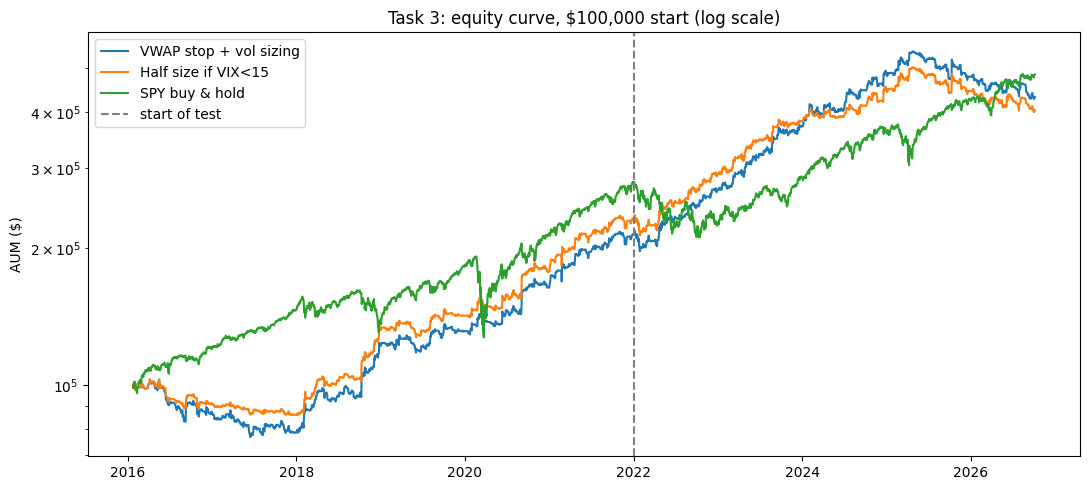

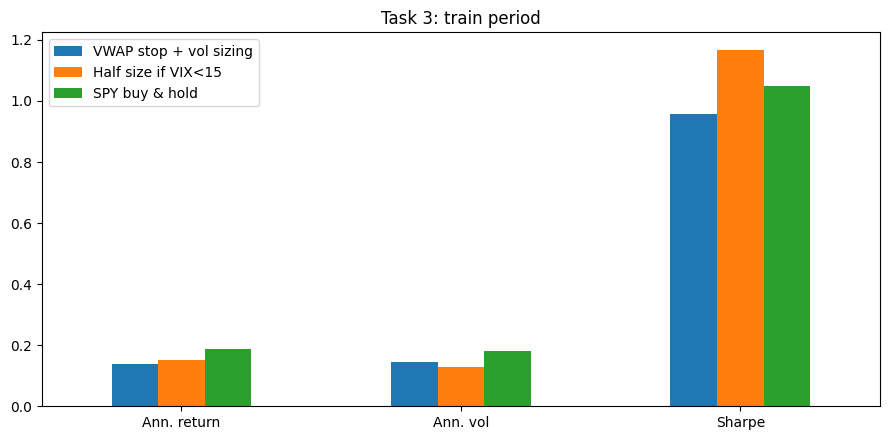

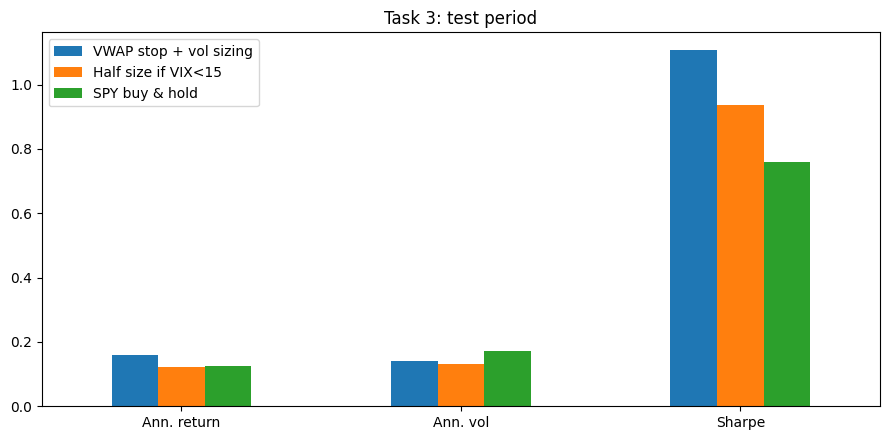

Ann. return  Ann. vol  Sharpe  Max DD  Hit ratio
VWAP stop + vol sizing train         0.14      0.15    0.96   -0.25       0.42
                       test          0.16      0.14    1.11   -0.21       0.46
Half size if VIX<15    train         0.15      0.13    1.17   -0.17       0.42
                       test          0.12      0.13    0.94   -0.20       0.46
SPY buy & hold         train         0.19      0.18    1.05   -0.34       0.57
                       test          0.12      0.17    0.76   -0.24       0.54

,Ann. return,Ann. vol,Sharpe,Max DD,Hit ratio
VWAP stop + vol sizing,0.15,0.14,1.02,-0.25,0.44
Half size if VIX<15,0.14,0.13,1.06,-0.20,0.44
SPY buy & hold,0.16,0.18,0.92,-0.34,0.55


ΔSharpe = 0.039, 95% CI [-0.074, 0.162]


In [44]:
res['Half size if VIX<15'] = backtest(pos_ext, lev_vol.where(~calm, lev_vol * 0.5))
r_half = res['Half size if VIX<15']['ret']

names3 = ['VWAP stop + vol sizing', 'Half size if VIX<15', 'SPY buy & hold']
table3 = metric_table(names3)
plot_results(names3, table3, 'Task 3')
display(table3.round(2))
display(pd.DataFrame({n: metrics(res[n]['ret']) for n in names3}).T.round(2))   # full sample

d = []
for _ in range(B):
    idx = block_idx(len(r_paper), block, rng)
    d.append(sharpe(pd.Series(r_half.values[idx])) - sharpe(pd.Series(r_paper.values[idx])))
print(f'ΔSharpe = {sharpe(r_half) - sharpe(r_paper):.3f}, 95% CI [{np.percentile(d, 2.5):.3f}, {np.percentile(d, 97.5):.3f}]')

In [45]:
r_half = res['Half size if VIX<15']['ret']
pd.DataFrame({'avg VIX':         v.groupby(v.index.year).mean(),
              'Sharpe paper':    r_paper.groupby(r_paper.index.year).apply(sharpe),
              'Sharpe half <15': r_half.groupby(r_half.index.year).apply(sharpe)}).T.round(2)

date,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
avg VIX,15.53,11.14,16.63,15.57,29.52,19.83,25.98,17.12,15.69,19.19,18.46
Sharpe paper,-0.89,-0.86,2.54,0.70,1.52,1.90,1.66,2.56,1.95,-0.05,-0.99
Sharpe half <15,-0.75,-0.95,2.67,0.82,1.55,1.90,1.66,2.40,1.43,-0.00,-0.96


* Train: Sharpe ratio 1.17 vs 0.96, maximum drawdown −17% vs −25%.
* Test: Sharpe ratio 0.94 vs 1.11, annualized return 12% vs 16%.
* Full sample: Sharpe ratio 1.06 vs 1.02, volatility 13% vs 14%, maximum drawdown −20% vs −25%.
* The Sharpe difference of +0.04 has a 95% confidence interval of about [−0.07, +0.16] and is not significant.
* By year, the rule improves results in 2016, 2018 and 2019 and reduces them most in 2023 and 2024 (2024: 1.95 → 1.43).

## Task 3: discussion

**Hypothesis.** Intraday momentum depends on order imbalances and should therefore be weaker on calm days. Reducing exposure when the VIX is low should improve risk-adjusted performance.

**Method.** The threshold (VIX = 15) is the lower tercile of the VIX distribution and is set without reference to strategy returns. Each regime contains about 900 days. Confidence intervals are obtained with a block bootstrap that preserves the clustering of volatility regimes.

**Results.**
1. Calm days have a significantly lower mean return than the remaining days (−2.6 bp per day), in line with the paper.
2. Their mean return is still slightly positive, so halving exposure mainly reduces risk rather than losses.
3. The relation is not stable over time: calm days were weak in 2016–2019 and strong in 2023–2026.
4. The rule reduces volatility (14% → 13%) and maximum drawdown (−25% → −20%). The increase in the Sharpe ratio (+0.04) is not significant, and in the test period the rule underperforms.

**Conclusion.** Lower exposure on calm days works as risk reduction but does not reliably improve risk-adjusted returns. The VIX measures expected volatility, whereas the strategy depends on intraday trends; the two were related in 2016–2019 but not in 2023–2024.

**Possible improvements.**
* A direct measure of trend persistence, such as the recent success rate of breakouts or the autocorrelation of intraday returns, instead of the VIX level.
* Continuous scaling of exposure instead of a fixed threshold, re-estimated on a rolling basis.
* The VIX term structure (VIX vs VIX3M) as an alternative stress indicator.